# Image processing notebook: From overlap corrected to transmission 

### 00 - Introduction
This notebook demonstrates the use of Jupyter for a Time-of-Flight image processing task. The data corresponds to ToF neutron imaging of coin cells filled with different organic compounds and electrolytes.

*Note: This notebook was written and tested on Windows 10. Running on Mac or Linux machines may need adjustments, e.g. in the path specificationsApplied processing*

### Applied processing
The following processing parts from the averaged pulses, which were already overlap corrected:

- filtering
- Pulse averaging and separtion per experiments
- identification and weighting of OBs for each experiment
- scrubbing correction
- intensity correction
- transmission image generation


### Important Considerations
This notebook starts from the point **after** the overlap correction presented in the image below. This step before (done in a separate notebook) format its destionation directory to be taken by this notebook to process the images correctly.

Transmission Image:

\begin{equation}
T_{img} \rightarrow \frac{I}{I_{0}}=\frac{\frac{\bar{Img}}{OB_{weight}} - SBKG_{img}}{\frac{\bar{Ref}}{OB_{weight}} - SBKG_{ref}}
\end{equation}

## 01 Initial settings
Import all the required libraries

In [1]:
import sys
sys.path.append(r'..\framework')
sys.path.append(r'..\proc_functions')
from proc_functions import *
from img_proc_functions import *
%matplotlib inline

### Select directories
Select the source directory. This directory is where the images **after** the overlap correction were saved.
Select the destination directory. Here is where the transmission images are going to be saved.

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\testing_overlap_corrected_sa\exp1XX"

In [3]:
# %load select_directory('dst_dir')
dst_dir = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\00_new_framweork_results\exp1XX_SA"

### Select working folders
Once the directories are loaded, you can start to do a selection of the folders you want to process. <br>
The next function loads the folders availableas a visual aid. However, you can avoid this step just by looking at the source folder in the windows explorer.

In [4]:
test_dict = prep_stack_dict(src_dir)
for key in test_dict.keys():
    print(key)

00_ob
01_so_ref
02_sa
02_sa_2_2
03_ob_end


For this test we will select some folders that we want to process as '`proc_folder`' and our reference as '`ref_folder`'.

* _note: `proc-folder` can take several strings as value, for that reason is a list of strings. On the other hand, `ref_folder` is always one, for that reason it is just a string._

In [5]:
proc_folder = ['02_sa']

proc_ref_folder = ['01_so_ref']

## 02 choose sequence for filters and pre-processing

In [6]:
seq = [crop_img, outlier_removal]
seq = list(sequence_separator(seq, lambda i, j: i.__name__ == "stack_avg"))
seq = list(filter(None, seq))

## 03 give the parameters needed for the pre-processing

In [7]:
param_dict = dict (roi_crop = [1, 356, 509, 129], threshold = 0)

## 04 keep the folders needed and read the images

In [8]:
test_dict = prep_stack_dict (src_dir)
weights = weighting_func (src_dir)

keep_folder = proc_folder 
keep_key_weights (test_dict, weights, keep_folder)

# we slice just for checking purposes
#test_dict = slice_vals_dict (test_dict, start_slice = 30, end_slice = 50)

get_imgs_dict(test_dict)

Reading Images: 100%|████████████████████████████| 3/3 [00:17<00:00,  5.97s/it]


## 05 do the pre-processing for the experiment

In [9]:
for idx in range (len(seq)):
    func_names = str([func.__name__ for func in seq[idx]])
    if seq[idx] == []:
        seq[idx].pop()
    #print(func_names)
    if 'stack_avg' in func_names:
        test_dict = exec_avg_dict(test_dict, sequence = seq[idx], **param_dict)
    else:
        test_dict = exec_proc_dict(test_dict, sequence = seq[idx], **param_dict)

Processing : 100%|███████████████████████████████| 6/6 [02:42<00:00, 27.12s/it]


## 06 milestone (checking headers and showing an image

In [10]:
list_imgs = [[item[0] for item in sub_val] for sub_val in test_dict[proc_folder[0]]]
test_img = np.nanmean(list_imgs, axis = 0)

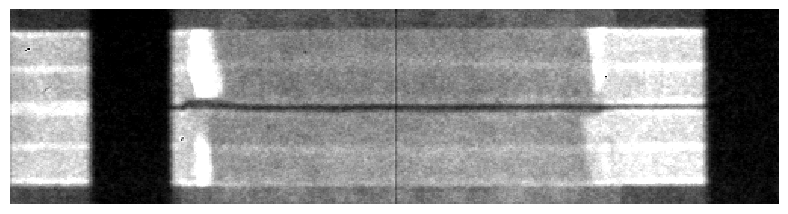

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  512                                                  
NAXIS2  =                  512                                                  
EXTEND  =                    T                                                  
TIMESTMP= 'Tue Aug 24 13:17:28 2021'                                            
TIME_DAT=         1629803848.0                                                  
COMMENT User: Ricardo Carreon                                                   
HISTORY Process: Crop image. ROI cropped = [1, 356, 509, 129]                   
HISTORY Process: Outlier removal. Threshold = 0                                 

In [11]:
show_img (test_img[0])
show_img (test_img[0], keep_fig =True)


hdr = test_vals = test_dict[proc_folder[0]][0][3][1]
img = (test_img[0], hdr)
hdr

## 07 Perform Scrubbing Correction

In [12]:
test_dict = scrubbing_corr_dict (test_dict, weights)

Processing Scrubbing Correction: 100%|█████████| 24/24 [00:01<00:00, 22.00it/s]


## 08 Perform Image registration

In [13]:
reg_img = get_img(src_dir + '/reg_img_LE.fits')

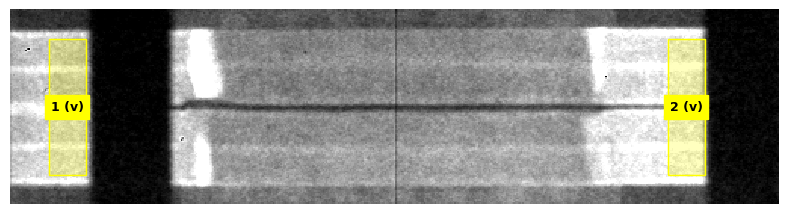

In [14]:
reg_rois = [([25, 19, 25, 90], 'v'), ([435, 19, 25, 90], 'v')]
show_img_rois(img[0], dr = [(reg_rois, 'yellow')])

In [15]:
disp = float(0.58335)
M = np.array([[1,0,disp], [0,1,0], [0,0,1]])
img_reg_corr, M = img_registration (img, reg_img, rois_list = reg_rois, dof=['ty'], M=M)

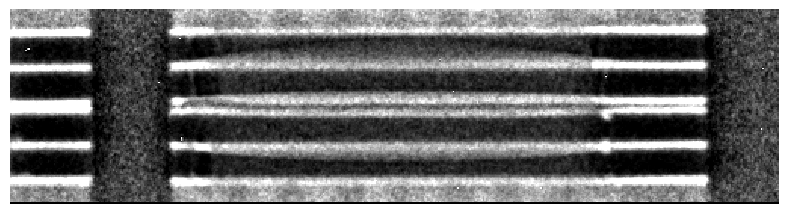

[[1.      0.      0.58335]
 [0.      1.      0.     ]
 [0.      0.      1.     ]]


In [16]:
plt.rcParams['figure.figsize'] = [15, 8]
show_img(img_reg_corr[0]/reg_img[0], cmap = 'gray')
print(M)

In [17]:
ref_mask_img = get_img(src_dir + '/bb_mask.fits')
img_mask_img = get_img(src_dir + '/bb_mask.fits')
reg_img = get_img(src_dir + '/reg_img_LE.fits')

reg_rois =  [([432, 19, 27, 90], 'v'),([23, 19, 27, 90], 'v')]

test_dict = img_registration_dict (test_dict, ref = reg_img, rois_list = reg_rois, dof=['ty'], M=M)

Processing Image Registration: 100%|███████████| 24/24 [00:07<00:00,  3.38it/s]


## 09 SBKG correction

In [18]:
test_dict = SBKG_correction_dict (test_dict, img_mask_img)

Processing SBKG Correction: 100%|██████████████| 24/24 [01:32<00:00,  3.85s/it]


## 10 TFC correction

In [19]:
# %load select_rois(img, list_rois = ['nca'])
nca = [404, 74, 51, 10]

### Do same process for the ref

In [20]:
ref_dict = prep_stack_dict (src_dir)
weights = weighting_func (src_dir)

keep_folder = proc_ref_folder 
keep_key_weights (ref_dict, weights, keep_folder)

# we slice just for checking purposes
#ref_dict = slice_vals_dict (ref_dict, start_slice = 30, end_slice = 50)

get_imgs_dict(ref_dict)

for idx in range (len(seq)):
    func_names = str([func.__name__ for func in seq[idx]])
    if seq[idx] == []:
        seq[idx].pop()
    #print(func_names)
    if 'stack_avg' in func_names:
        ref_dict = exec_avg_dict(ref_dict, sequence = seq[idx], count_time = False, **param_dict)
    else:
        ref_dict = exec_proc_dict(ref_dict, sequence = seq[idx] , count_time = False, **param_dict)

ref_dict = scrubbing_corr_dict (ref_dict, weights)
ref_dict = img_registration_dict (ref_dict, ref = reg_img, rois_list = reg_rois, dof=['ty'], M=M)
ref_dict = SBKG_correction_dict (ref_dict, ref_mask_img)

Processing SBKG Correction: 100%|██████████████| 25/25 [01:50<00:00,  4.43s/it]


In [21]:
ref_avg_img = avg_tof_imgs_dict (ref_dict, output_type = 'img')

test_dict = avg_TFC_correction_dict (test_dict, ref_avg_img, nca = nca, use_ref=False)

Processing TFC Correction: 100%|███████████████| 24/24 [00:01<00:00, 21.20it/s]


## 11 Save results

In [22]:
param_dict.update(start_img_numb = 0)
save_dict (test_dict, dst_dir, img_type = 'transmission_img_SA', **param_dict )

Saving Images: 100%|███████████████████████████| 24/24 [03:14<00:00,  8.12s/it]


In [28]:
len(new_dict.values())

1

In [29]:
new_dict={}
new_dict [proc_folder[0]] = [avg_tof_imgs_dict (test_dict, output_type = 'tof')]

In [30]:
dst_dir = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\00_new_framweork_results\exp1XX_SA_avg"
save_dict (new_dict, dst_dir, img_type = 'transmission_img_avg_SA', **param_dict )

Saving Images: 100%|█████████████████████████████| 1/1 [00:06<00:00,  6.32s/it]
